# Step 4 - Crank-Nicolson Method

Crank-Nicolson (CN) averages the implicit and explicit operators 50/50 at each time step.
This gives **second-order accuracy** in both time and space, vs first-order in time for the implicit method.

At each step we solve:
$$A \, V^{n+1} = B \, V^n$$
where $A$ uses the new time level (implicit half) and $B$ uses the old time level (explicit half).

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.solvers.crank_nicolson import solve_crank_nicolson
from src.solvers.implicit import solve_implicit
from src.core import bs_price

## Parameters

In [7]:
K     = 100
r     = 0.05
sigma = 0.20
T     = 1.0
S_max = 3 * K

M = 200
N = 200

## 1. Price vs Stock Price - CN vs Implicit vs Black-Scholes

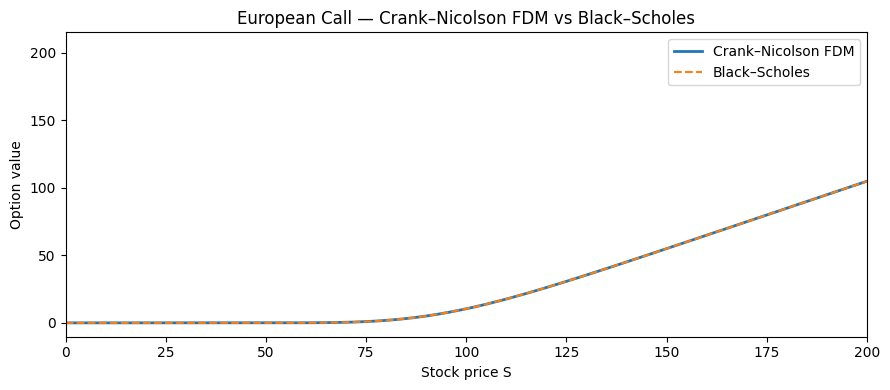

In [8]:
S, V_call = solve_crank_nicolson(S_max, K, r, sigma, T, M, N, option_type='call')

# Closed-form benchmark
bs_call = np.array([bs_price(s, K, T, r, sigma, option_type='call') for s in S])

plt.figure(figsize=(9, 4))
plt.plot(S, V_call, label='Crank–Nicolson FDM', lw=2)
plt.plot(S, bs_call, '--', label='Black–Scholes', lw=1.5)
plt.xlim(0, 200)
plt.xlabel('Stock price S')
plt.ylabel('Option value')
plt.title('European Call — Crank–Nicolson FDM vs Black–Scholes')
plt.legend()
plt.tight_layout()
plt.savefig('../results/04_cn_call.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Point Validation at S = K = 100

In [9]:
S0 = 100.0
exact_call = bs_price(S0, K, T, r, sigma, option_type='call')
exact_put  = bs_price(S0, K, T, r, sigma, option_type='put')

Sc, Vc_call = solve_crank_nicolson(S_max, K, r, sigma, T, M, N, option_type='call')
Sp, Vc_put  = solve_crank_nicolson(S_max, K, r, sigma, T, M, N, option_type='put')
Si, Vi_call = solve_implicit(S_max, K, r, sigma, T, M, N, option_type='call')
Sip, Vi_put = solve_implicit(S_max, K, r, sigma, T, M, N, option_type='put')

print(f"{'':15s} {'FDM':>10s} {'Exact':>10s} {'Error':>10s}")
print(f"{'CN Call':15s} {np.interp(S0, Sc, Vc_call):10.4f} {exact_call:10.4f} {abs(np.interp(S0, Sc, Vc_call) - exact_call):10.6f}")
print(f"{'CN Put':15s} {np.interp(S0, Sp, Vc_put):10.4f}  {exact_put:10.4f} {abs(np.interp(S0, Sp, Vc_put) - exact_put):10.6f}")
print(f"{'Implicit Call':15s} {np.interp(S0, Si, Vi_call):10.4f} {exact_call:10.4f} {abs(np.interp(S0, Si, Vi_call) - exact_call):10.6f}")
print(f"{'Implicit Put':15s} {np.interp(S0, Sip, Vi_put):10.4f}  {exact_put:10.4f} {abs(np.interp(S0, Sip, Vi_put) - exact_put):10.6f}")

                       FDM      Exact      Error
CN Call            10.4544    10.4506   0.003854
CN Put              5.5774      5.5735   0.003854
Implicit Call      10.4492    10.4506   0.001388
Implicit Put        5.5727      5.5735   0.000793


## 3. Convergence Comparison

CN is second-order in time, so its error should shrink **faster** than implicit as the grid is refined.

Note: at coarse grids CN can appear less accurate than implicit. The call payoff has a kink at $S=K$ (non-smooth initial condition) which excites small oscillations in CN that the fully-implicit scheme damps naturally. These disappear as the grid is refined.

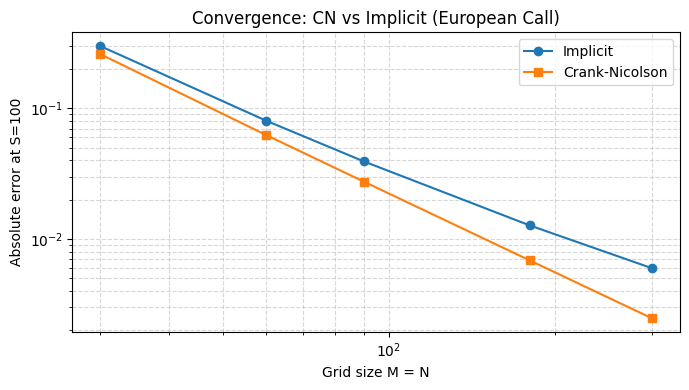

In [10]:
grid_sizes  = [30, 60, 90, 180, 300]  # multiples of 3 so S0=100 lands exactly on the grid
errors_cn   = []
errors_imp  = []
exact = bs_price(S0, K, T, r, sigma, option_type='call')

for n in grid_sizes:
    Sc, Vc = solve_crank_nicolson(S_max, K, r, sigma, T, M=n, N=n, option_type='call')
    Si, Vi = solve_implicit(S_max, K, r, sigma, T, M=n, N=n, option_type='call')
    errors_cn.append(abs(np.interp(S0, Sc, Vc) - exact))
    errors_imp.append(abs(np.interp(S0, Si, Vi) - exact))

plt.figure(figsize=(7, 4))
plt.loglog(grid_sizes, errors_imp, 'o-', label='Implicit')
plt.loglog(grid_sizes, errors_cn,  's-', label='Crank-Nicolson')
plt.xlabel('Grid size M = N')
plt.ylabel('Absolute error at S=100')
plt.title('Convergence: CN vs Implicit (European Call)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../results/04_cn_convergence.png', dpi=150, bbox_inches='tight')
plt.show()